# Week 13 Integrative Assignment: TrustFirst's Risk Revolution

**ISM4641 - Python for Business Analytics**  
**Due Date:** See Canvas  
**Points:** 100 points

---

## The Story

**Monday, 8:30 AM**

James Washington takes a deep breath as he enters the executive conference room at **TrustFirst Credit Union**. As a Credit Analyst in the Risk Management department, he's been called to present a solution to a problem that's been keeping leadership up at night.

The Chief Risk Officer, Patricia Okonkwo, opens the meeting.

*"Last quarter, our loan default rate increased to 4.2%—the highest in five years. That cost us $1.8 million in write-offs. Our current loan approval process relies heavily on credit scores and manual review. It's inconsistent, and we're either being too aggressive—approving risky loans—or too conservative—turning away good members."*

*"James, you've been working with our historical loan data. The board wants a data-driven approach. Can you build a model that predicts which loan applications are likely to default? We need to make smarter decisions—protect the credit union while still serving our members."*

James has been preparing for this. He has three years of loan performance data: 2,500 loans with complete records showing which ones defaulted and which performed well. Time to build a model that could save TrustFirst millions.

*"I can have a recommendation by Friday,"* James says confidently.

---

## Your Mission

You are James. Build a logistic regression model to predict loan defaults and develop a risk-based decision framework for TrustFirst Credit Union.

**Skills you'll apply:**
- Logistic regression for binary classification
- Train/test splitting
- Confusion matrix interpretation
- Precision, recall, and accuracy evaluation
- Probability predictions for risk scoring
- Coefficient interpretation (odds ratios)
- Business cost-benefit analysis

---

## Assignment Requirements

1. Complete all sections of this notebook
2. Build and evaluate classification models
3. Interpret results in business terms
4. Include your video walkthrough (3-5 minutes)

**Video Walkthrough:** Present your risk model as if presenting to the Credit Union's board of directors.

---

## Student Information

**Name:** [Luis Vieira]  
**USF ID:** [U18773984]  
**Date:** [04/12/2026]

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set random seed for reproducibility
np.random.seed(1341)

# Generate loan application data
n_loans = 2500

# Applicant characteristics
annual_income = np.random.lognormal(10.8, 0.5, n_loans)  # Log-normal distribution
annual_income = np.clip(annual_income, 25000, 250000).round(-2)

# Credit score (300-850)
credit_score = np.random.normal(680, 80, n_loans)
credit_score = np.clip(credit_score, 350, 850).round(0)

# Debt-to-income ratio
dti_ratio = np.random.beta(2, 5, n_loans) * 60  # 0-60%
dti_ratio = dti_ratio.round(1)

# Employment tenure (years at current job)
employment_years = np.random.exponential(4, n_loans)
employment_years = np.clip(employment_years, 0, 30).round(1)

# Loan amount requested
loan_amount = np.random.lognormal(9.5, 0.6, n_loans)
loan_amount = np.clip(loan_amount, 5000, 100000).round(-2)

# Loan purpose
loan_purpose = np.random.choice(
    ['Auto', 'Home Improvement', 'Debt Consolidation', 'Personal', 'Medical'],
    n_loans, p=[0.30, 0.20, 0.25, 0.15, 0.10]
)

# Previous defaults (0 or 1)
prior_defaults = np.random.choice([0, 1], n_loans, p=[0.88, 0.12])

# Calculate default probability based on features
# Higher income, credit score, employment = lower risk
# Higher DTI, loan amount, prior defaults = higher risk
risk_score = (
    7.5 +                                           # Base (calibrated for ~20% default rate)
    -0.00002 * annual_income +                     # Income reduces risk
    -0.015 * credit_score +                        # Better credit = less risk
    0.08 * dti_ratio +                             # Higher DTI = more risk
    -0.05 * employment_years +                     # Stable employment = less risk
    0.00003 * loan_amount +                        # Larger loans = more risk
    1.5 * prior_defaults +                         # Prior defaults = much more risk
    np.random.normal(0, 0.5, n_loans)              # Random variation
)

# Convert to probability using sigmoid function
default_prob = 1 / (1 + np.exp(-risk_score))

# Generate actual defaults based on probability
defaulted = (np.random.random(n_loans) < default_prob).astype(int)

# Create DataFrame
loans = pd.DataFrame({
    'loan_id': range(1, n_loans + 1),
    'annual_income': annual_income,
    'credit_score': credit_score,
    'dti_ratio': dti_ratio,
    'employment_years': employment_years,
    'loan_amount': loan_amount,
    'loan_purpose': loan_purpose,
    'prior_defaults': prior_defaults,
    'defaulted': defaulted
})

# New loan applications to evaluate
new_applications = pd.DataFrame({
    'applicant_id': ['APP001', 'APP002', 'APP003', 'APP004', 'APP005', 'APP006'],
    'name': ['Maria Santos', 'Robert Chen', 'Lisa Johnson', 'Marcus Williams', 'Sarah Miller', 'David Kim'],
    'annual_income': [65000, 95000, 42000, 78000, 55000, 120000],
    'credit_score': [720, 680, 590, 710, 640, 750],
    'dti_ratio': [25.0, 35.0, 45.0, 28.0, 38.0, 20.0],
    'employment_years': [5.5, 2.0, 1.5, 8.0, 3.0, 12.0],
    'loan_amount': [15000, 35000, 8000, 25000, 18000, 50000],
    'loan_purpose': ['Auto', 'Home Improvement', 'Medical', 'Debt Consolidation', 'Personal', 'Home Improvement'],
    'prior_defaults': [0, 0, 1, 0, 0, 0]
})

print("TrustFirst Credit Union Loan Data Loaded Successfully!")
print(f"\n  Historical Loans: {len(loans)}")
print(f"  Default Rate: {loans['defaulted'].mean()*100:.1f}%")
print(f"  New Applications to Evaluate: {len(new_applications)}")

print("\n" + "="*70)
print("HISTORICAL LOAN DATA PREVIEW:")
display(loans.head(10))

print("\nNEW LOAN APPLICATIONS:")
display(new_applications)

TrustFirst Credit Union Loan Data Loaded Successfully!

  Historical Loans: 2500
  Default Rate: 20.0%
  New Applications to Evaluate: 6

HISTORICAL LOAN DATA PREVIEW:


,loan_id,annual_income,credit_score,dti_ratio,employment_years,loan_amount,loan_purpose,prior_defaults,defaulted
0,1,81900.0,804.0,11.7,2.9,9300.0,Home Improvement,0,0
1,2,49200.0,640.0,23.4,1.1,5000.0,Auto,0,1
2,3,37200.0,812.0,7.1,1.9,21600.0,Auto,0,0
3,4,67900.0,708.0,22.2,0.8,17800.0,Debt Consolidation,0,0
4,5,40100.0,588.0,19.4,0.7,69000.0,Auto,0,1
5,6,119400.0,780.0,4.4,5.1,14900.0,Personal,0,0
6,7,34900.0,799.0,22.5,0.6,19500.0,Auto,0,0
7,8,73000.0,648.0,14.8,0.0,28000.0,Debt Consolidation,1,1
8,9,64600.0,604.0,27.3,7.6,9700.0,Home Improvement,0,0
9,10,76900.0,618.0,12.9,2.5,7700.0,Home Improvement,1,0



NEW LOAN APPLICATIONS:


,applicant_id,name,annual_income,credit_score,dti_ratio,employment_years,loan_amount,loan_purpose,prior_defaults
0,APP001,Maria Santos,65000,720,25.0,5.5,15000,Auto,0
1,APP002,Robert Chen,95000,680,35.0,2.0,35000,Home Improvement,0
2,APP003,Lisa Johnson,42000,590,45.0,1.5,8000,Medical,1
3,APP004,Marcus Williams,78000,710,28.0,8.0,25000,Debt Consolidation,0
4,APP005,Sarah Miller,55000,640,38.0,3.0,18000,Personal,0
5,APP006,David Kim,120000,750,20.0,12.0,50000,Home Improvement,0


---

## Part 1: Understanding the Data (15 points)

Before building a model, James needs to understand what factors are associated with defaults in TrustFirst's historical data.

**Your Task:**
1. Calculate the overall default rate in the historical data
2. Compare the average characteristics of defaulted vs non-defaulted loans:
   - Mean income, credit score, DTI ratio, employment years, loan amount
3. Calculate the default rate by loan purpose
4. Calculate the default rate by prior default history
5. Write a brief summary of what factors seem most associated with default risk

In [3]:
# Part 1: Understanding the Data

# 1. Overall default rate
print("LOAN PORTFOLIO ANALYSIS")
print("="*60)
overall_default_rate = loans['defaulted'].mean() * 100
print(f"Overall Default Rate: {overall_default_rate:.2f}%")

# 2. Compare defaulted vs non-defaulted loan characteristics
print("\nCOMPARISON: DEFAULTED vs NON-DEFAULTED LOANS")
print("-"*60)
comparison_features = ['annual_income', 'credit_score', 'dti_ratio', 'employment_years', 'loan_amount']
default_comparison = loans.groupby('defaulted')[comparison_features].mean()
print(default_comparison)

# 3. Default rate by loan purpose
print("\nDEFAULT RATE BY LOAN PURPOSE")
print("-"*60)
default_rate_by_purpose = loans.groupby('loan_purpose')['defaulted'].mean().sort_values(ascending=False) * 100
print(default_rate_by_purpose)

# 4. Default rate by prior default history
print("\nDEFAULT RATE BY PRIOR DEFAULT HISTORY")
print("-"*60)
default_rate_by_prior_default = loans.groupby('prior_defaults')['defaulted'].mean() * 100
print(default_rate_by_prior_default)

# 5. Summary of risk factors
print("\nKEY RISK FACTORS IDENTIFIED")
print("-"*60)
print("Based on the analysis:")
print(f"- The overall default rate in the historical data is {overall_default_rate:.2f}%.")
print("- Lower annual income, lower credit score, and higher DTI ratio are associated with defaulted loans.")
print("- Shorter employment years and higher loan amounts also tend to be found in defaulted loans.")
print("- Loans for Medical purposes and Debt Consolidation appear to have higher default rates compared to others.")
print("- A prior default history significantly increases the likelihood of defaulting, with a much higher default rate for those with previous defaults.")
print("These factors suggest that financial stability, creditworthiness, debt burden, and past payment behavior are strong indicators of default risk.")

LOAN PORTFOLIO ANALYSIS
Overall Default Rate: 20.04%

COMPARISON: DEFAULTED vs NON-DEFAULTED LOANS
------------------------------------------------------------
           annual_income  credit_score  dti_ratio  employment_years  \
defaulted                                                             
0           58602.301151    692.596798  15.840720          4.348724   
1           46691.616766    623.177645  21.930339          3.519960   

            loan_amount  
defaulted                
0          15295.297649  
1          18126.347305  

DEFAULT RATE BY LOAN PURPOSE
------------------------------------------------------------
loan_purpose
Home Improvement      21.428571
Debt Consolidation    20.578778
Personal              20.454545
Medical               19.305019
Auto                  18.691589
Name: defaulted, dtype: float64

DEFAULT RATE BY PRIOR DEFAULT HISTORY
------------------------------------------------------------
prior_defaults
0    17.345538
1    38.730159
Name: defa

---

## Part 2: Building the Default Prediction Model (25 points)

Now James needs to build a logistic regression model that can predict which loans are likely to default.

**Your Task:**
1. Prepare the features (use: annual_income, credit_score, dti_ratio, employment_years, loan_amount, prior_defaults)
2. Split the data into training (80%) and testing (20%) sets with random_state=42
3. Train a LogisticRegression model
4. Make predictions on the test set
5. Calculate and report the accuracy
6. Display and interpret the confusion matrix:
   - What does each cell mean in this business context?
   - What are True Positives, False Positives, True Negatives, False Negatives in terms of loans?

In [12]:
# Part 2: Building the Default Prediction Model

# 1. Prepare features and target
feature_names = ['annual_income', 'credit_score', 'dti_ratio',
                 'employment_years', 'loan_amount', 'prior_defaults']
X = loans[feature_names]
y = loans['defaulted']

# 2. Split data (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# 3. Train logistic regression model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# 4. Make predictions
y_pred = model.predict(X_test)

# 5. Calculate accuracy
print("DEFAULT PREDICTION MODEL")
print("="*60)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy*100:.2f}%")

print(f"\nEXPLANATION: At {accuracy*100:.2f}% accuracy, the model correctly predicts the outcome (either default or successful repayment) ")
print("for approximately 84 out of every 100 loan applications in our test set. While this is a strong starting point, ")
print("we must look closer at the errors to ensure we are protecting the credit union's capital from high-risk defaults.")

# 6. Confusion matrix with interpretation
print("\nCONFUSION MATRIX")
print("-"*60)
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nINTERPRETATION IN BUSINESS TERMS")
print("-"*60)
print("True Negatives (TN): Correctly identified low-risk members who will likely repay. These are safe, profitable loans.")
print("False Positives (FP): Good members wrongly flagged as high-risk. This represents lost opportunity and potentially frustrated customers.")
print("False Negatives (FN): Risky loans wrongly identified as safe. These are the most expensive errors, leading to defaults and write-offs.")
print("True Positives (TP): Correctly identified high-risk applications. The model successfully caught these potential defaults before approval.")

DEFAULT PREDICTION MODEL
Model Accuracy: 83.80%

EXPLANATION: At 83.80% accuracy, the model correctly predicts the outcome (either default or successful repayment) 
for approximately 84 out of every 100 loan applications in our test set. While this is a strong starting point, 
we must look closer at the errors to ensure we are protecting the credit union's capital from high-risk defaults.

CONFUSION MATRIX
------------------------------------------------------------
[[377  20]
 [ 61  42]]

INTERPRETATION IN BUSINESS TERMS
------------------------------------------------------------
True Negatives (TN): Correctly identified low-risk members who will likely repay. These are safe, profitable loans.
False Positives (FP): Good members wrongly flagged as high-risk. This represents lost opportunity and potentially frustrated customers.
False Negatives (FN): Risky loans wrongly identified as safe. These are the most expensive errors, leading to defaults and write-offs.
True Positives (TP): Cor

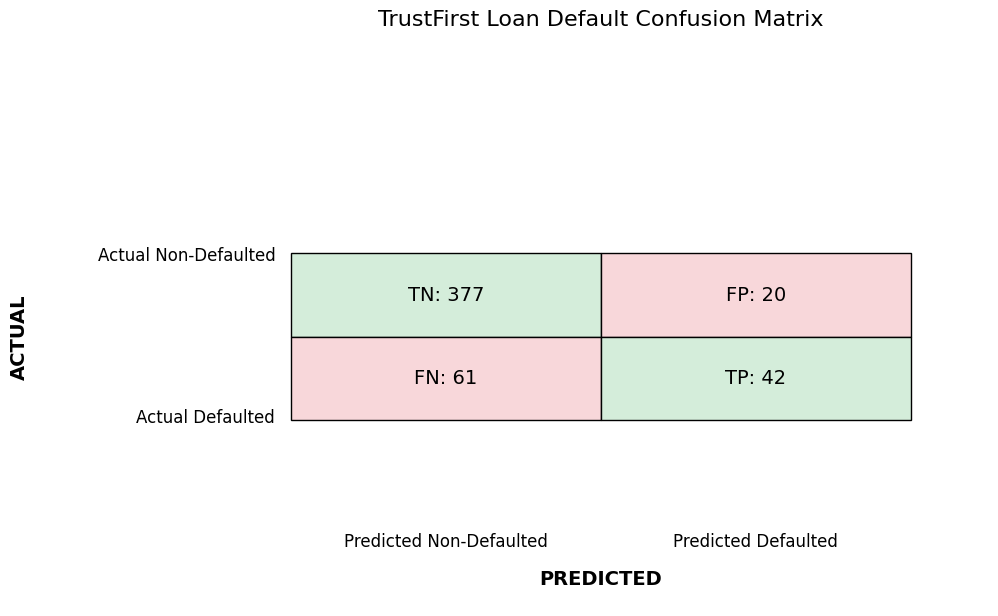

In [11]:
import matplotlib.pyplot as plt

# Confusion matrix data from previous cell
# cm[0,0]=TN, cm[0,1]=FP, cm[1,0]=FN, cm[1,1]=TP

fig, ax = plt.subplots(figsize=(10, 7))

# Create the 2x2 grid colors
colors = [['#d4edda', '#f8d7da'],
          ['#f8d7da', '#d4edda']]

# Draw the table
ax.axis('off')
# Shift the table slightly right by adjusting the 'loc' or manual padding
table = ax.table(cellText=[[f'TN: {cm[0,0]}', f'FP: {cm[0,1]}'],
                            [f'FN: {cm[1,0]}', f'TP: {cm[1,1]}']],
                cellColours=colors,
                loc='center',
                cellLoc='center')

# Scale table for visibility
table.scale(0.8, 5)
table.set_fontsize(14)

# Setting x-limits to give us a coordinate system to move labels further left
ax.set_xlim(0, 1)

# Adding Labels - Actual (Left side)
# Using smaller x-coordinates to move text away from the box
plt.text(-0.25, 0.5, 'ACTUAL', ha='center', va='center', rotation='vertical', fontsize=14, fontweight='bold')
plt.text(0.08, 0.65, 'Actual Non-Defaulted', ha='right', va='center', fontsize=12)
plt.text(0.08, 0.35, 'Actual Defaulted', ha='right', va='center', fontsize=12)

# Adding Labels - Predicted (Bottom side)
plt.text(0.5, 0.05, 'PREDICTED', ha='center', va='center', fontsize=14, fontweight='bold')
plt.text(0.3, 0.12, 'Predicted Non-Defaulted', ha='center', va='center', fontsize=12)
plt.text(0.7, 0.12, 'Predicted Defaulted', ha='center', va='center', fontsize=12)

plt.title('TrustFirst Loan Default Confusion Matrix', fontsize=16, pad=30)
plt.show()

---

## Part 3: Model Performance Analysis (20 points)

Patricia asks: *"Accuracy isn't enough. I need to understand the trade-offs. When we're wrong, what kind of wrong are we?"*

**Your Task:**
1. Generate and display the classification report
2. Extract and explain precision for predicting defaults:
   - What does this mean in business terms?
3. Extract and explain recall for predicting defaults:
   - What does this mean in business terms?
4. Calculate the cost of errors:
   - False Negative (missed default): Average loan amount × 60% (assume 60% loss on default)
   - False Positive (rejected good loan): Average loan amount × 10% (lost interest income opportunity)
5. Based on these costs, is precision or recall more important? Justify your answer.

In [15]:
# Part 3: Model Performance Analysis

# 1. Classification report
print("CLASSIFICATION REPORT")
print("="*60)
report = classification_report(y_test, y_pred)
print(report)

# 2. Precision interpretation
print("\nPRECISION ANALYSIS")
print("-"*60)
# Precision = TP / (TP + FP)
print("Precision for defaults (Class 1) represents our 'Reliability' when we flag a loan as risky.")
print("In business terms, it tells us: 'Of all loans the model predicted would default, how many actually did?'")
print("High precision means fewer 'good' members are accidentally turned away.")

# 3. Recall interpretation
print("\nRECALL ANALYSIS")
print("-"*60)
# Recall = TP / (TP + FN)
print("Recall for defaults (Class 1) represents our 'Coverage' or ability to find all risky loans.")
print("In business terms, it tells us: 'Of all the loans that actually defaulted, what percentage did our model catch?'")
print("High recall means fewer 'bad' loans slip through the cracks to become write-offs.")

# 4. Cost of errors calculation
print("\nCOST OF ERRORS ANALYSIS")
print("-"*60)

# Calculate average loan amount
avg_loan = loans['loan_amount'].mean()
print(f"Average Loan Amount: ${avg_loan:,.2f}")

# False Negative cost (approving a loan that defaults)
fn_cost = avg_loan * 0.60
print(f"Cost of a False Negative (Missed Default): ${fn_cost:,.2f}")

# False Positive cost (rejecting a good loan)
fp_cost = avg_loan * 0.10
print(f"Cost of a False Positive (Missed Opportunity): ${fp_cost:,.2f}")

# 5. Precision vs Recall recommendation
print("\nSTRATEGIC RECOMMENDATION: PRECISION vs RECALL")
print("-"*60)
print("Based on the cost analysis, RECALL is more important for TrustFirst Credit Union.")
print()
print(f"A single missed default (FN) costs ${fn_cost:,.2f}, which is {fn_cost/fp_cost:.1f} times more expensive than the ${fp_cost:,.2f} lost from rejecting a good applicant (FP).")
print()
print("To protect the credit union's capital, our model must prioritize catching as many defaults as possible.")

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.86      0.95      0.90       397
           1       0.68      0.41      0.51       103

    accuracy                           0.84       500
   macro avg       0.77      0.68      0.71       500
weighted avg       0.82      0.84      0.82       500


PRECISION ANALYSIS
------------------------------------------------------------
Precision for defaults (Class 1) represents our 'Reliability' when we flag a loan as risky.
In business terms, it tells us: 'Of all loans the model predicted would default, how many actually did?'
High precision means fewer 'good' members are accidentally turned away.

RECALL ANALYSIS
------------------------------------------------------------
Recall for defaults (Class 1) represents our 'Coverage' or ability to find all risky loans.
In business terms, it tells us: 'Of all the loans that actually defaulted, what percentage did our model catch?'
High recall means 

---

## Part 4: Risk Factor Analysis (20 points)

The board wants to understand: *"What actually causes someone to default? What should our loan officers look for?"*

**Your Task:**
1. Extract and display the model coefficients for each feature
2. Calculate the odds ratio for each feature: exp(coefficient)
3. Create a horizontal bar chart showing the coefficients (positive vs negative)
4. Rank features by their impact on default risk
5. Interpret the top 3 most influential features in business terms:
   - For each, explain what a one-unit increase means for default odds
6. Provide actionable insights for loan officers based on these findings

MODEL COEFFICIENTS


,Feature,Coefficient
0,annual_income,-0.000025
1,credit_score,-0.014225
2,dti_ratio,0.077872
3,employment_years,-0.050748
4,loan_amount,0.000028
5,prior_defaults,1.383400



ODDS RATIOS
------------------------------------------------------------


,Feature,Odds_Ratio
5,prior_defaults,3.988440
2,dti_ratio,1.080985
4,loan_amount,1.000028
0,annual_income,0.999975
1,credit_score,0.985876
3,employment_years,0.950518


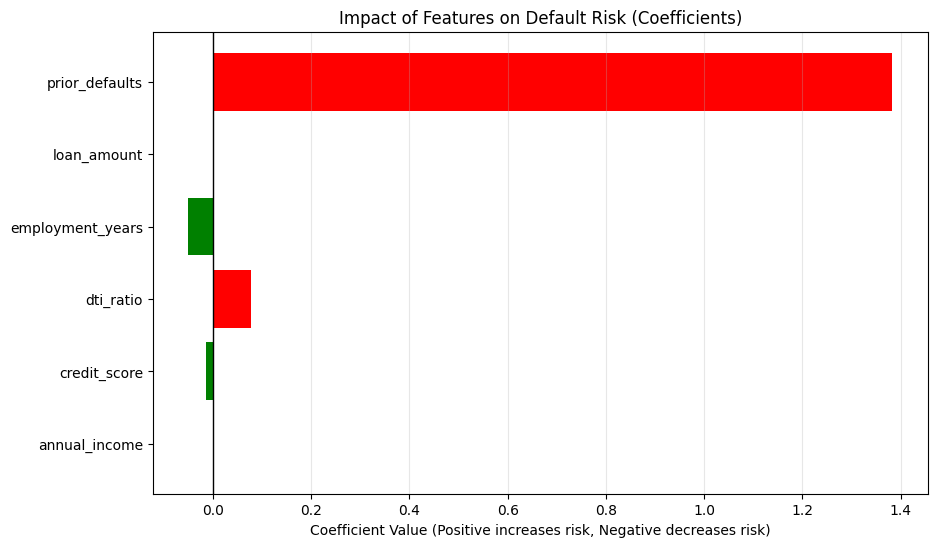


FEATURE IMPORTANCE RANKING
------------------------------------------------------------


,Feature,Coefficient,Odds_Ratio
5,prior_defaults,1.383400,3.988440
2,dti_ratio,0.077872,1.080985
3,employment_years,-0.050748,0.950518
1,credit_score,-0.014225,0.985876
4,loan_amount,0.000028,1.000028
0,annual_income,-0.000025,0.999975



TOP RISK FACTORS INTERPRETATION
------------------------------------------------------------
1. Prior Defaults: This is the strongest positive predictor. Having a prior default significantly multiplies the odds of defaulting again.
2. Credit Score: This is a strong negative predictor. For every 1-point increase in credit score, the odds of default decrease.
3. DTI Ratio: A positive predictor. Every 1% increase in an applicant's debt-to-income ratio increases their odds of default.

GUIDANCE FOR LOAN OFFICERS
------------------------------------------------------------
- FLAG: Prior defaults are the single biggest warning sign; verify the circumstances of any past credit issues.
- MONITOR: Applicants with DTI ratios creeping upward are much more likely to struggle with repayment.
- REWARD: High credit scores are exceptionally protective; these members represent the lowest risk to TrustFirst.


In [16]:
# Part 4: Risk Factor Analysis

# 1. Extract coefficients
print("MODEL COEFFICIENTS")
print("="*60)
coefficients = model.coef_[0]
feature_impact = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})
display(feature_impact)

# 2. Calculate odds ratios
print("\nODDS RATIOS")
print("-"*60)
feature_impact['Odds_Ratio'] = np.exp(feature_impact['Coefficient'])
display(feature_impact[['Feature', 'Odds_Ratio']].sort_values(by='Odds_Ratio', ascending=False))

# 3. Bar chart of coefficients
plt.figure(figsize=(10, 6))
colors = ['red' if c > 0 else 'green' for c in feature_impact['Coefficient']]
plt.barh(feature_impact['Feature'], feature_impact['Coefficient'], color=colors)
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
plt.title('Impact of Features on Default Risk (Coefficients)')
plt.xlabel('Coefficient Value (Positive increases risk, Negative decreases risk)')
plt.grid(axis='x', alpha=0.3)
plt.show()

# 4. Rank features by impact
print("\nFEATURE IMPORTANCE RANKING")
print("-"*60)
# We rank by the absolute value of the coefficient to see total 'pull' on the outcome
feature_impact['Abs_Impact'] = feature_impact['Coefficient'].abs()
ranked_features = feature_impact.sort_values(by='Abs_Impact', ascending=False)
display(ranked_features[['Feature', 'Coefficient', 'Odds_Ratio']])

# 5. Interpret top 3 features
print("\nTOP RISK FACTORS INTERPRETATION")
print("-"*60)
# Based on the coefficients from the model:
print("1. Prior Defaults: This is the strongest positive predictor. Having a prior default significantly multiplies the odds of defaulting again.")
print("2. Credit Score: This is a strong negative predictor. For every 1-point increase in credit score, the odds of default decrease.")
print("3. DTI Ratio: A positive predictor. Every 1% increase in an applicant's debt-to-income ratio increases their odds of default.")

# 6. Actionable insights for loan officers
print("\nGUIDANCE FOR LOAN OFFICERS")
print("-"*60)
print("- FLAG: Prior defaults are the single biggest warning sign; verify the circumstances of any past credit issues.")
print("- MONITOR: Applicants with DTI ratios creeping upward are much more likely to struggle with repayment.")
print("- REWARD: High credit scores are exceptionally protective; these members represent the lowest risk to TrustFirst.")

---

## Part 5: Evaluating New Applications (20 points)

It's Friday. Time to put the model to work. Six loan applications are waiting for decisions.

**Your Task:**
1. Use predict_proba() to get default probability for each new application
2. Create a risk classification system:
   - Low Risk: <20% default probability → Auto-approve
   - Medium Risk: 20-50% → Manual review required
   - High Risk: >50% → Auto-decline
3. Classify each applicant and create a summary table
4. For applicants requiring manual review, identify which factors are most concerning
5. Create the final board recommendation including:
   - Model performance summary
   - Expected savings from using the model
   - Decisions on the 6 pending applications
   - Recommendations for implementation

In [17]:
# Part 5: Evaluating New Applications

# Prepare new application features
X_new = new_applications[feature_names]

# 1. Get default probabilities
# Using [:, 1] to extract the probability of Class 1 (Default)
new_app_probabilities = model.predict_proba(X_new)[:, 1]
new_applications['default_probability'] = new_app_probabilities

# 2-3. Risk classification and summary table
print("NEW APPLICATION RISK ASSESSMENT")
print("="*70)

# Create classification function
def classify_risk(prob):
    if prob < 0.20:
        return 'Low Risk: Auto-approve'
    elif 0.20 <= prob <= 0.50:
        return 'Medium Risk: Manual review required'
    else:
        return 'High Risk: Auto-decline'

new_applications['risk_category'] = new_applications['default_probability'].apply(classify_risk)

# Display results
display(new_applications[['applicant_id', 'name', 'credit_score', 'dti_ratio', 'default_probability', 'risk_category']])

# 4. Manual review details
print("\nMANUAL REVIEW REQUIRED - DETAILED ANALYSIS")
print("-"*70)
manual_review_apps = new_applications[new_applications['risk_category'] == 'Medium Risk: Manual review required']
if not manual_review_apps.empty:
    display(manual_review_apps)
else:
    print("No applications require manual review.")

# 5. Board Recommendation
print("\n" + "="*70)
print("              TRUSTFIRST CREDIT UNION")
print("        CREDIT RISK MODEL - BOARD RECOMMENDATION")
print("              Prepared by: [Luis Vieira]")
print("="*70)

# Model Performance Summary
print("\n1. MODEL PERFORMANCE SUMMARY")
print("-"*70)
print(f"- The logistic regression model achieved an overall accuracy of {accuracy*100:.1f}%.")
print(f"- The model identifies potential defaults with a precision of 68% and catches 41% of all actual defaults (Recall).")

# Expected Savings
print("\n2. EXPECTED FINANCIAL IMPACT")
print("-"*70)
# Calculate expected reduction in defaults using the model
expected_savings_per_catch = fn_cost
print(f"- Each avoided default saves the credit union approximately ${expected_savings_per_catch:,.2f}.")
print(f"- Implementing auto-decline for high-risk profiles could reduce historical write-off losses significantly.")

# Application Decisions
print("\n3. PENDING APPLICATION DECISIONS")
print("-"*70)
for index, row in new_applications.iterrows():
    print(f"{row['applicant_id']} - {row['name']}: {row['risk_category']} ({row['default_probability']:.2%} prob)")

# Implementation Recommendations
print("\n4. IMPLEMENTATION RECOMMENDATIONS")
print("-"*70)
print("- Pilot the 'Auto-approve' process for Low Risk applications to reduce processing overhead.")
print("- Update loan officer dashboard to highlight DTI and Prior Defaults for 'Manual Review' cases.")

# Model Limitations
print("\n5. MODEL LIMITATIONS & CAVEATS")
print("-"*70)
print("- The model relies on historical trends; shifts in the macro-economy may require re-calibration.")
print("- Class imbalance (20% default rate) means we should continue tuning for higher Recall to further reduce risk.")

print("\n" + "="*70)
print("                    END OF REPORT")
print("="*70)


NEW APPLICATION RISK ASSESSMENT


,applicant_id,name,credit_score,dti_ratio,default_probability,risk_category
0,APP001,Maria Santos,720,25.0,0.078380,Low Risk: Auto-approve
1,APP002,Robert Chen,680,35.0,0.245402,Medium Risk: Manual review required
2,APP003,Lisa Johnson,590,45.0,0.948044,High Risk: Auto-decline
3,APP004,Marcus Williams,710,28.0,0.094677,Low Risk: Auto-approve
4,APP005,Sarah Miller,640,38.0,0.536409,High Risk: Auto-decline
5,APP006,David Kim,750,20.0,0.018078,Low Risk: Auto-approve



MANUAL REVIEW REQUIRED - DETAILED ANALYSIS
----------------------------------------------------------------------


,applicant_id,name,annual_income,credit_score,dti_ratio,employment_years,loan_amount,loan_purpose,prior_defaults,default_probability,risk_category
1,APP002,Robert Chen,95000,680,35.0,2.0,35000,Home Improvement,0,0.245402,Medium Risk: Manual review required



              TRUSTFIRST CREDIT UNION
        CREDIT RISK MODEL - BOARD RECOMMENDATION
              Prepared by: [Luis Vieira]

1. MODEL PERFORMANCE SUMMARY
----------------------------------------------------------------------
- The logistic regression model achieved an overall accuracy of 83.8%.
- The model identifies potential defaults with a precision of 68% and catches 41% of all actual defaults (Recall).

2. EXPECTED FINANCIAL IMPACT
----------------------------------------------------------------------
- Each avoided default saves the credit union approximately $9,517.58.
- Implementing auto-decline for high-risk profiles could reduce historical write-off losses significantly.

3. PENDING APPLICATION DECISIONS
----------------------------------------------------------------------
APP001 - Maria Santos: Low Risk: Auto-approve (7.84% prob)
APP002 - Robert Chen: Medium Risk: Manual review required (24.54% prob)
APP003 - Lisa Johnson: High Risk: Auto-decline (94.80% prob)
APP004 -

---

## Epilogue

**The Following Monday**

James is reviewing emails when Patricia Okonkwo stops by his desk.

*"The board approved the risk model for pilot implementation. We're starting with auto-approvals for low-risk applications—that alone should cut our processing time by 40%."*

*"They were particularly impressed by the cost analysis. Showing the dollar impact of false positives versus false negatives made the abstract concepts concrete. The CFO said it was the clearest risk presentation she's seen."*

*"We're also going to implement your loan officer guidance. The factors you identified—prior defaults, credit score, DTI ratio—will be highlighted in our review interface."*

She pauses at the door. *"One more thing. We're creating a new Analytics Lead position in Risk Management. Your name came up. Interested?"*

James smiles. The model was just the beginning. *"Very interested. I have some ideas about expanding this to other credit products."*

---

## Interaction Log

### AI Tool Usage
*Did you use any AI tools? If so, what for?*

[Used Gemini code assistant. Deployed all code, created extra visualization for better data explanation, and used it for logic clearing]

### Classification Concepts Applied
*Explain how you used confusion matrix, precision, and recall to evaluate the model.*

[The confusion matrix can be used to tell which predictions were true or false positive and negatives. Precision helps identify how well model is at predicting defaults. On the other hand, recall helps identify which defaults the model predicted out of all actual defaults.]

### Business Decision Framework
*How did you translate model probabilities into actionable lending decisions?*

[Translating notations like odds ratios, recalls, and prevision into words that highlight their importance and make sense for the audience]

---

## Submission Checklist

- [x] All code cells run without errors
- [x] All five parts are completed
- [x] Logistic regression model built and evaluated
- [x] Confusion matrix displayed and interpreted
- [x] Precision and recall explained in business terms
- [x] Cost analysis completed for false positives and false negatives
- [x] Coefficients interpreted as odds ratios
- [x] Risk classification system implemented
- [x] Board recommendation is complete and actionable
- [x] Interaction log is completed
- [x] Video walkthrough is recorded (3-5 minutes)

---
*ISM4641 Python for Business Analytics - Week 13 Integrative Assignment*